In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split, GridSearchCV
import tensorflow as tf

In [3]:
# Load your dataset
# Assuming you have a CSV file or a DataFrame
df = pd.read_csv('../../data/Tdata.csv')

# Inspecting the first few rows of the data
print(df.head())

       Date  User Count Average  Average User Throughput DL  \
0  1-Apr-23            23286.87                    5.633309   
1  1-Aug-23            23677.76                    7.364028   
2  1-Dec-22            20755.21                    5.066298   
3  1-Feb-23            21880.87                    5.382316   
4  1-Jan-23            20811.78                    5.389850   

   Average User Throughput UL       CSSR  DL_256QAM_PROPORTION  DL_LATENCY  \
0                    0.679596  98.804118              0.988493   12.778676   
1                    0.471457  95.325628              0.820870    7.653198   
2                    0.644504  97.453779              0.917099   10.162252   
3                    0.792096  98.227500              1.016471   12.823051   
4                    0.704850  98.747444              0.939248   10.303647   

   DL_PACK_LOSS_RATE  DL_QPSK_PROPORTION  Data Volume DL  User Count Maximum  \
0           0.317022           34.709118     43047497.21               4

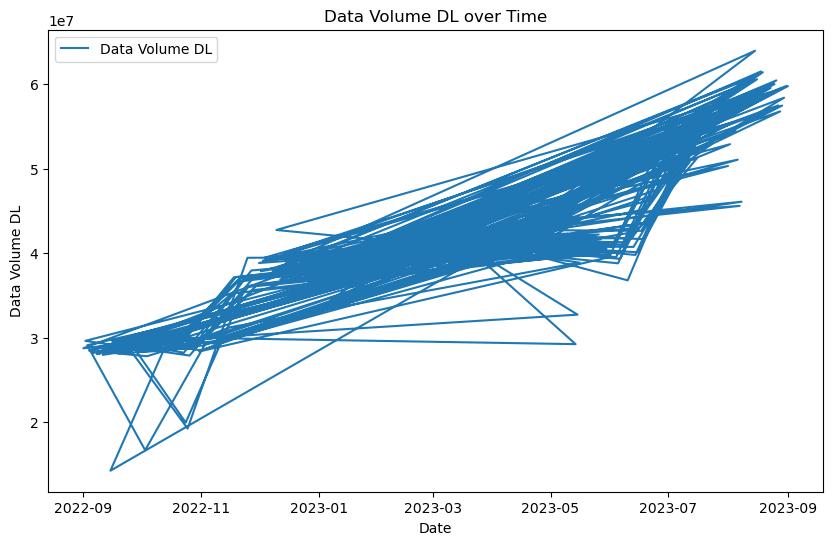

In [4]:
# Extract the 'Date' and 'Data Volume DL' columns for forecasting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Plot the data to visualize the trend
plt.figure(figsize=(10, 6))
plt.plot(df['Data Volume DL'], label='Data Volume DL')
plt.title('Data Volume DL over Time')
plt.xlabel('Date')
plt.ylabel('Data Volume DL')
plt.legend()
plt.show()

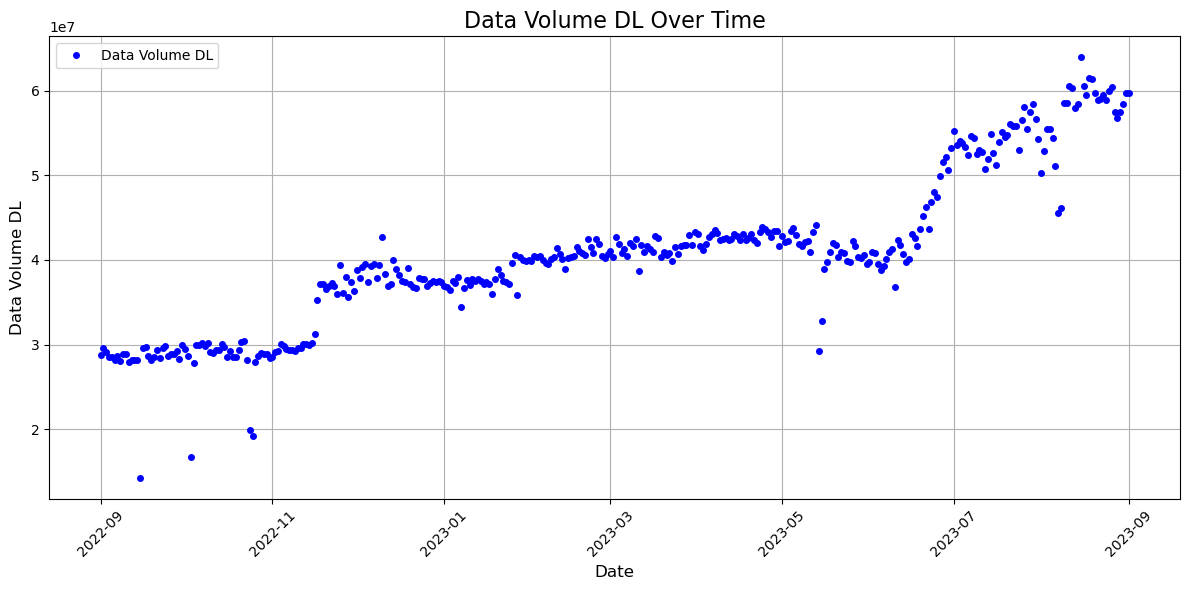

In [5]:
# Plot the data with markers only
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Data Volume DL'], 'o', color='blue', markersize=4, label='Data Volume DL')  # 'o' for scatter plot
plt.title('Data Volume DL Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Data Volume DL', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Data Preprocessing
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Data Volume DL']])

In [7]:
# Convert time series into a supervised learning problem
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)


In [8]:
# Define time step
time_step = 10
X, y = create_dataset(scaled_data, time_step)

# Reshape input to be [samples, time steps, features] for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [9]:
# Build the LSTM model
def build_model(units=50, dropout_rate=0.2, optimizer='adam'):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

In [10]:
# Hyperparameter tuning using grid search
def tune_hyperparameters():
    param_grid = {
        'units': [50, 100],
        'dropout_rate': [0.2, 0.3],
        'optimizer': ['adam', 'rmsprop'],
        'batch_size': [32, 64],
        'epochs': [50, 100]
    }
    
    model = tf.keras.wrappers.scikit_learn.KerasRegressor(build_fn=build_model, verbose=0)
    
    grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error')
    grid_result = grid.fit(X_train, y_train)
    
    print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")
    return grid_result.best_params_


Training with units=50, dropout_rate=0.2, batch_size=32, epochs=50, optimizer=adam
Epoch 1/50
9/9 [==============================] - 17s 388ms/step - loss: 0.1833 - val_loss: 0.1385 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0655 - val_loss: 0.0218 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0109 - val_loss: 0.0045 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0138 - val_loss: 0.0011 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0084 - val_loss: 0.0083 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0094 - val_loss: 0.0039 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0073 - val_loss: 6.0799e-04 - lr: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0078 - val_loss: 0.0015 - lr: 0.0010
Epoch 9/50
9/9 [===============

9/9 [==============================] - 0s 21ms/step - loss: 0.0068 - val_loss: 0.0012 - lr: 4.0000e-05
Epoch 22/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0072 - val_loss: 0.0013 - lr: 4.0000e-05
Epoch 23/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0063 - val_loss: 0.0013 - lr: 4.0000e-05
Epoch 24/100
9/9 [==============================] - 0s 30ms/step - loss: 0.0062 - val_loss: 0.0013 - lr: 1.0000e-05
Epoch 25/100
9/9 [==============================] - 0s 24ms/step - loss: 0.0068 - val_loss: 0.0013 - lr: 1.0000e-05
Epoch 26/100
3/3 [==============================] - 2s 7ms/step
MSE: 60587445286749.32
Training with units=50, dropout_rate=0.2, batch_size=64, epochs=50, optimizer=adam
Epoch 1/50
5/5 [==============================] - 12s 583ms/step - loss: 0.1526 - val_loss: 0.1236 - lr: 0.0010
Epoch 2/50
5/5 [==============================] - 0s 26ms/step - loss: 0.0757 - val_loss: 0.0449 - lr: 0.0010
Epoch 3/50
5/5 [=========================

5/5 [==============================] - 0s 27ms/step - loss: 0.0592 - val_loss: 0.0284 - lr: 0.0010
Epoch 3/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0161 - val_loss: 0.0036 - lr: 0.0010
Epoch 4/100
5/5 [==============================] - 0s 31ms/step - loss: 0.0086 - val_loss: 6.2706e-04 - lr: 0.0010
Epoch 5/100
5/5 [==============================] - 0s 31ms/step - loss: 0.0091 - val_loss: 0.0042 - lr: 0.0010
Epoch 6/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0093 - val_loss: 9.1545e-04 - lr: 0.0010
Epoch 7/100
5/5 [==============================] - 0s 33ms/step - loss: 0.0091 - val_loss: 6.5042e-04 - lr: 0.0010
Epoch 8/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0074 - val_loss: 6.6330e-04 - lr: 0.0010
Epoch 9/100
5/5 [==============================] - 0s 31ms/step - loss: 0.0088 - val_loss: 0.0039 - lr: 0.0010
Epoch 10/100
5/5 [==============================] - 0s 27ms/step - loss: 0.0068 - val_loss: 0.0019 - lr: 2.0

Epoch 2/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0125 - val_loss: 0.0038 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0109 - val_loss: 0.0024 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0090 - val_loss: 0.0079 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0088 - val_loss: 0.0197 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0095 - val_loss: 0.0014 - lr: 0.0010
Epoch 7/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0084 - val_loss: 7.2479e-04 - lr: 0.0010
Epoch 8/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0089 - val_loss: 0.0036 - lr: 0.0010
Epoch 9/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0100 - val_loss: 6.1950e-04 - lr: 0.0010
Epoch 10/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0079 - val_loss: 0.0017 - lr:

5/5 [==============================] - 11s 609ms/step - loss: 0.1518 - val_loss: 0.0784 - lr: 0.0010
Epoch 2/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0444 - val_loss: 0.0147 - lr: 0.0010
Epoch 3/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0138 - val_loss: 0.0080 - lr: 0.0010
Epoch 4/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0108 - val_loss: 6.9920e-04 - lr: 0.0010
Epoch 5/100
5/5 [==============================] - 0s 31ms/step - loss: 0.0118 - val_loss: 0.0018 - lr: 0.0010
Epoch 6/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0108 - val_loss: 7.5188e-04 - lr: 0.0010
Epoch 7/100
5/5 [==============================] - 0s 29ms/step - loss: 0.0096 - val_loss: 8.3081e-04 - lr: 0.0010
Epoch 8/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0099 - val_loss: 0.0015 - lr: 0.0010
Epoch 9/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0097 - val_loss: 0.0055 - lr: 0.0010

...

9/9 [==============================] - 0s 25ms/step - loss: 0.0119 - val_loss: 0.0100 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0057 - val_loss: 0.0016 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0057 - val_loss: 0.0026 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 40ms/step - loss: 0.0044 - val_loss: 6.4873e-04 - lr: 0.0010
Epoch 7/100
9/9 [==============================] - 0s 27ms/step - loss: 0.0047 - val_loss: 0.0013 - lr: 0.0010
Epoch 8/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0044 - val_loss: 9.5844e-04 - lr: 0.0010
Epoch 9/100
9/9 [==============================] - 0s 50ms/step - loss: 0.0042 - val_loss: 9.6641e-04 - lr: 0.0010
Epoch 10/100
9/9 [==============================] - 0s 51ms/step - loss: 0.0040 - val_loss: 7.6921e-04 - lr: 0.0010
Epoch 11/100
9/9 [==============================] - 1s 109ms/step - loss: 0.0037 - val_loss: 8.7414e-04 - l

Epoch 12/50
5/5 [==============================] - 0s 55ms/step - loss: 0.0061 - val_loss: 0.0070 - lr: 0.0010
Epoch 13/50
5/5 [==============================] - 0s 50ms/step - loss: 0.0051 - val_loss: 0.0126 - lr: 0.0010
Epoch 14/50
5/5 [==============================] - 0s 47ms/step - loss: 0.0071 - val_loss: 0.0081 - lr: 0.0010
Epoch 15/50
5/5 [==============================] - 0s 56ms/step - loss: 0.0060 - val_loss: 0.0025 - lr: 2.0000e-04
Epoch 16/50
5/5 [==============================] - 0s 52ms/step - loss: 0.0037 - val_loss: 6.9748e-04 - lr: 2.0000e-04
Epoch 17/50
5/5 [==============================] - 0s 50ms/step - loss: 0.0034 - val_loss: 6.2834e-04 - lr: 2.0000e-04
Epoch 18/50
5/5 [==============================] - 0s 47ms/step - loss: 0.0044 - val_loss: 0.0018 - lr: 2.0000e-04
Epoch 19/50
5/5 [==============================] - 0s 51ms/step - loss: 0.0040 - val_loss: 8.2670e-04 - lr: 2.0000e-04
Epoch 20/50
5/5 [==============================] - 0s 54ms/step - loss: 0.0039 -

Epoch 24/100
3/3 [==============================] - 2s 5ms/step
MSE: 34545492136519.34
Training with units=150, dropout_rate=0.3, batch_size=32, epochs=50, optimizer=adam
Epoch 1/50
9/9 [==============================] - 18s 384ms/step - loss: 0.1141 - val_loss: 0.0014 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0190 - val_loss: 0.0016 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0083 - val_loss: 0.0094 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0060 - val_loss: 9.5796e-04 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0062 - val_loss: 0.0027 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0051 - val_loss: 9.2569e-04 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0050 - val_loss: 8.8907e-04 - lr: 0.0010
Epoch 8/50
9/9 [=============================

Epoch 19/100
9/9 [==============================] - 0s 42ms/step - loss: 0.0045 - val_loss: 8.7141e-04 - lr: 4.0000e-05
Epoch 20/100
9/9 [==============================] - 0s 34ms/step - loss: 0.0044 - val_loss: 9.1656e-04 - lr: 4.0000e-05
Epoch 21/100
9/9 [==============================] - 0s 43ms/step - loss: 0.0043 - val_loss: 9.5162e-04 - lr: 1.0000e-05
Epoch 22/100
9/9 [==============================] - 0s 34ms/step - loss: 0.0043 - val_loss: 9.6099e-04 - lr: 1.0000e-05
Epoch 23/100
3/3 [==============================] - 3s 11ms/step
MSE: 31836562090746.04
Training with units=150, dropout_rate=0.3, batch_size=32, epochs=100, optimizer=rmsprop
Epoch 1/100
9/9 [==============================] - 18s 324ms/step - loss: 0.0658 - val_loss: 0.0059 - lr: 0.0010
Epoch 2/100
9/9 [==============================] - 0s 30ms/step - loss: 0.0061 - val_loss: 0.0048 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 0s 27ms/step - loss: 0.0067 - val_loss: 0.0085 - lr: 0.0010
Epoch 4/1

Epoch 1/100
5/5 [==============================] - 16s 727ms/step - loss: 0.1482 - val_loss: 0.0509 - lr: 0.0010
Epoch 2/100
5/5 [==============================] - 0s 47ms/step - loss: 0.0184 - val_loss: 0.0198 - lr: 0.0010
Epoch 3/100
5/5 [==============================] - 0s 48ms/step - loss: 0.0285 - val_loss: 0.0021 - lr: 0.0010
Epoch 4/100
5/5 [==============================] - 0s 49ms/step - loss: 0.0066 - val_loss: 0.0121 - lr: 0.0010
Epoch 5/100
5/5 [==============================] - 0s 44ms/step - loss: 0.0120 - val_loss: 0.0094 - lr: 0.0010
Epoch 6/100
5/5 [==============================] - 0s 50ms/step - loss: 0.0076 - val_loss: 7.0118e-04 - lr: 0.0010
Epoch 7/100
5/5 [==============================] - 0s 42ms/step - loss: 0.0065 - val_loss: 7.5509e-04 - lr: 0.0010
Epoch 8/100
5/5 [==============================] - 0s 47ms/step - loss: 0.0062 - val_loss: 0.0020 - lr: 0.0010
Epoch 9/100
5/5 [==============================] - 0s 50ms/step - loss: 0.0051 - val_loss: 0.0051 - lr

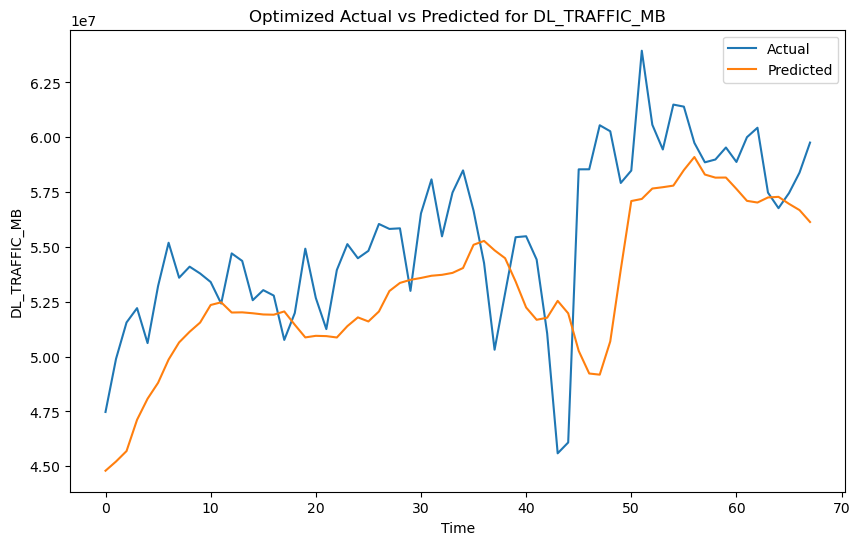

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for LSTM with adjustable look_back
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    
    # Adding multiple LSTM layers with Dropout
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Preparing data for 'DL_TRAFFIC_MB'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'DL_TRAFFIC_MB' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM with a larger look_back (increase past time steps to consider)
look_back = 5  # You can experiment with different values
X_train, y_train = create_dataset(train, look_back=look_back)
X_test, y_test = create_dataset(test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Manual hyperparameter tuning loop
best_mse = float('inf')
best_params = {}
best_model = None
best_history = None

# Loop through different hyperparameter configurations
for units in [50, 100, 150]:
    for dropout_rate in [0.2, 0.3]:
        for batch_size in [32, 64]:
            for epochs in [50, 100]:
                for optimizer in ['adam', 'rmsprop']:
                    print(f'Training with units={units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}')
                    
                    # Train model
                    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
                    
                    # Inverse scaling for the predictions and the actual test data
                    test_predict = scaler.inverse_transform(test_predict)
                    y_test_inverse = scaler.inverse_transform([y_test])
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_inverse[0], test_predict[:, 0])
                    print(f'MSE: {mse}')
                    
                    # Track the best model
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'units': units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}
                        best_model = model
                        best_history = history

print(f'Best MSE: {best_mse} with params: {best_params}')

# Plot the best model's predictions
best_test_predict = best_model.predict(X_test)
best_test_predict = scaler.inverse_transform(best_test_predict)

plt.figure(figsize=(10, 6))
plt.plot(scaler.inverse_transform([y_test])[0], label='Actual')
plt.plot(best_test_predict, label='Predicted')
plt.title(f'Optimized Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(feature)
plt.legend()
plt.show()

In [12]:
# Updated architecture with additional LSTM layer, increased patience, and possible Huber loss
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    
    # Adding multiple LSTM layers with Dropout
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(dropout_rate))
    
    # Adding a second and third LSTM layer for more depth
    model.add(LSTM(units // 2, return_sequences=True))
    model.add(Dropout(dropout_rate))
    
    model.add(LSTM(units // 4, return_sequences=False))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1))

    # Compile with Adam optimizer and Huber loss
    model.compile(optimizer=optimizer, loss='huber_loss')

    early_stop = EarlyStopping(monitor='val_loss', patience=15)  # Increased patience
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Training loop
for units in [50, 100, 150]:
    for dropout_rate in [0.2, 0.3]:
        for batch_size in [16, 32, 64]:
            for epochs in [50, 100, 150]:
                for optimizer in [Adam(learning_rate=0.0005), 'rmsprop']:  # Reduced learning rate
                    print(f'Training with units={units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}')
                    
                    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
                    
                    # Inverse scaling for the predictions and the actual test data
                    test_predict = scaler.inverse_transform(test_predict)
                    y_test_inverse = scaler.inverse_transform([y_test])
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_inverse[0], test_predict[:, 0])
                    print(f'MSE: {mse}')
                    
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'units': units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}
                        best_model = model
                        best_history = history

print(f'Best MSE: {best_mse} with params: {best_params}')

Training with units=50, dropout_rate=0.2, batch_size=16, epochs=50, optimizer=<keras.src.optimizers.adam.Adam object at 0x000002936EF34C50>
Epoch 1/50
15/15 [==============================] - 26s 317ms/step - loss: 0.0868 - val_loss: 0.0964 - lr: 5.0000e-04
Epoch 2/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0468 - val_loss: 0.0395 - lr: 5.0000e-04
Epoch 3/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0129 - val_loss: 0.0016 - lr: 5.0000e-04
Epoch 4/50
15/15 [==============================] - 0s 22ms/step - loss: 0.0074 - val_loss: 0.0024 - lr: 5.0000e-04
Epoch 5/50
15/15 [==============================] - 0s 22ms/step - loss: 0.0064 - val_loss: 0.0057 - lr: 5.0000e-04
Epoch 6/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0065 - val_loss: 0.0026 - lr: 5.0000e-04
Epoch 7/50
15/15 [==============================] - 0s 23ms/step - loss: 0.0049 - val_loss: 0.0029 - lr: 5.0000e-04
Epoch 8/50
15/15 [============================

Epoch 10/100
15/15 [==============================] - 0s 26ms/step - loss: 0.0037 - val_loss: 0.0016 - lr: 0.0010
Epoch 11/100
15/15 [==============================] - 0s 28ms/step - loss: 0.0043 - val_loss: 0.0013 - lr: 0.0010
Epoch 12/100
15/15 [==============================] - 0s 26ms/step - loss: 0.0040 - val_loss: 0.0013 - lr: 0.0010
Epoch 13/100
15/15 [==============================] - 0s 26ms/step - loss: 0.0037 - val_loss: 0.0021 - lr: 0.0010
Epoch 14/100
15/15 [==============================] - 0s 26ms/step - loss: 0.0033 - val_loss: 0.0014 - lr: 0.0010
Epoch 15/100
15/15 [==============================] - 0s 25ms/step - loss: 0.0028 - val_loss: 0.0017 - lr: 0.0010
Epoch 16/100
15/15 [==============================] - 0s 25ms/step - loss: 0.0036 - val_loss: 0.0017 - lr: 0.0010
Epoch 17/100
15/15 [==============================] - 0s 21ms/step - loss: 0.0032 - val_loss: 0.0017 - lr: 2.0000e-04
Epoch 18/100
15/15 [==============================] - 0s 18ms/step - loss: 0.0031 - 

8/8 [==============================] - 0s 43ms/step - loss: 0.0071 - val_loss: 0.0015 - lr: 5.0000e-04
Epoch 8/50
8/8 [==============================] - 0s 41ms/step - loss: 0.0076 - val_loss: 0.0018 - lr: 5.0000e-04
Epoch 9/50
8/8 [==============================] - 0s 43ms/step - loss: 0.0065 - val_loss: 0.0045 - lr: 5.0000e-04
Epoch 10/50
8/8 [==============================] - 0s 40ms/step - loss: 0.0064 - val_loss: 0.0041 - lr: 5.0000e-04
Epoch 11/50
8/8 [==============================] - 0s 45ms/step - loss: 0.0058 - val_loss: 0.0032 - lr: 5.0000e-04
Epoch 12/50
8/8 [==============================] - 0s 36ms/step - loss: 0.0055 - val_loss: 0.0029 - lr: 5.0000e-04
Epoch 13/50
8/8 [==============================] - 0s 36ms/step - loss: 0.0051 - val_loss: 0.0029 - lr: 1.0000e-04
Epoch 14/50
8/8 [==============================] - 0s 35ms/step - loss: 0.0052 - val_loss: 0.0030 - lr: 1.0000e-04
Epoch 15/50
8/8 [==============================] - 0s 32ms/step - loss: 0.0059 - val_loss: 0.0

8/8 [==============================] - 0s 27ms/step - loss: 0.0065 - val_loss: 0.0037 - lr: 0.0010
Epoch 4/100
8/8 [==============================] - 0s 27ms/step - loss: 0.0075 - val_loss: 0.0038 - lr: 0.0010
Epoch 5/100
8/8 [==============================] - 0s 32ms/step - loss: 0.0052 - val_loss: 0.0029 - lr: 0.0010
Epoch 6/100
8/8 [==============================] - 0s 29ms/step - loss: 0.0064 - val_loss: 0.0016 - lr: 0.0010
Epoch 7/100
8/8 [==============================] - 0s 29ms/step - loss: 0.0056 - val_loss: 0.0018 - lr: 0.0010
Epoch 8/100
8/8 [==============================] - 0s 28ms/step - loss: 0.0052 - val_loss: 0.0040 - lr: 0.0010
Epoch 9/100
8/8 [==============================] - 0s 35ms/step - loss: 0.0045 - val_loss: 0.0059 - lr: 0.0010
Epoch 10/100
8/8 [==============================] - 0s 34ms/step - loss: 0.0050 - val_loss: 0.0081 - lr: 0.0010
Epoch 11/100
8/8 [==============================] - 0s 36ms/step - loss: 0.0046 - val_loss: 0.0030 - lr: 0.0010
Epoch 12/10

8/8 [==============================] - 0s 20ms/step - loss: 0.0034 - val_loss: 0.0019 - lr: 4.0000e-05
Epoch 29/150
3/3 [==============================] - 4s 8ms/step
MSE: 48674328920717.33
Training with units=50, dropout_rate=0.2, batch_size=64, epochs=50, optimizer=<keras.src.optimizers.adam.Adam object at 0x000002937C8F5F50>
Epoch 1/50
4/4 [==============================] - 26s 1s/step - loss: 0.1048 - val_loss: 0.1390 - lr: 5.0000e-04
Epoch 2/50
4/4 [==============================] - 0s 46ms/step - loss: 0.0933 - val_loss: 0.1245 - lr: 5.0000e-04
Epoch 3/50
4/4 [==============================] - 0s 45ms/step - loss: 0.0824 - val_loss: 0.1101 - lr: 5.0000e-04
Epoch 4/50
4/4 [==============================] - 0s 47ms/step - loss: 0.0724 - val_loss: 0.0954 - lr: 5.0000e-04
Epoch 5/50
4/4 [==============================] - 0s 45ms/step - loss: 0.0612 - val_loss: 0.0801 - lr: 5.0000e-04
Epoch 6/50
4/4 [==============================] - 0s 48ms/step - loss: 0.0495 - val_loss: 0.0641 - lr

...

4/4 [==============================] - 0s 38ms/step - loss: 0.0028 - val_loss: 0.0018 - lr: 1.0000e-05
Epoch 32/150
4/4 [==============================] - 0s 47ms/step - loss: 0.0030 - val_loss: 0.0018 - lr: 1.0000e-05
Epoch 33/150
3/3 [==============================] - 5s 11ms/step
MSE: 58539483388031.164
Training with units=100, dropout_rate=0.3, batch_size=16, epochs=50, optimizer=<keras.src.optimizers.adam.Adam object at 0x00000293748BB5D0>
Epoch 1/50
15/15 [==============================] - 21s 234ms/step - loss: 0.0778 - val_loss: 0.0700 - lr: 5.0000e-04
Epoch 2/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0223 - val_loss: 0.0014 - lr: 5.0000e-04
Epoch 3/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0082 - val_loss: 0.0028 - lr: 5.0000e-04
Epoch 4/50
15/15 [==============================] - 0s 27ms/step - loss: 0.0068 - val_loss: 0.0039 - lr: 5.0000e-04
Epoch 5/50
15/15 [==============================] - 1s 36ms/step - loss: 0.0060 - val

15/15 [==============================] - 0s 18ms/step - loss: 0.0077 - val_loss: 0.0081 - lr: 0.0010
Epoch 3/100
15/15 [==============================] - 0s 25ms/step - loss: 0.0056 - val_loss: 0.0012 - lr: 0.0010
Epoch 4/100
15/15 [==============================] - 0s 18ms/step - loss: 0.0053 - val_loss: 0.0039 - lr: 0.0010
Epoch 5/100
15/15 [==============================] - 0s 15ms/step - loss: 0.0048 - val_loss: 0.0037 - lr: 0.0010
Epoch 6/100
15/15 [==============================] - 0s 15ms/step - loss: 0.0048 - val_loss: 0.0019 - lr: 0.0010
Epoch 7/100
15/15 [==============================] - 0s 15ms/step - loss: 0.0047 - val_loss: 0.0013 - lr: 0.0010
Epoch 8/100
15/15 [==============================] - 0s 17ms/step - loss: 0.0043 - val_loss: 0.0030 - lr: 0.0010
Epoch 9/100
15/15 [==============================] - 0s 16ms/step - loss: 0.0038 - val_loss: 0.0021 - lr: 2.0000e-04
Epoch 10/100
15/15 [==============================] - 0s 16ms/step - loss: 0.0039 - val_loss: 0.0019 - l

8/8 [==============================] - 0s 21ms/step - loss: 0.0051 - val_loss: 0.0019 - lr: 1.0000e-04
Epoch 15/50
8/8 [==============================] - 0s 19ms/step - loss: 0.0049 - val_loss: 0.0020 - lr: 1.0000e-04
Epoch 16/50
8/8 [==============================] - 0s 24ms/step - loss: 0.0043 - val_loss: 0.0019 - lr: 1.0000e-04
Epoch 17/50
8/8 [==============================] - 0s 39ms/step - loss: 0.0048 - val_loss: 0.0019 - lr: 1.0000e-04
Epoch 18/50
8/8 [==============================] - 0s 30ms/step - loss: 0.0045 - val_loss: 0.0019 - lr: 1.0000e-04
Epoch 19/50
8/8 [==============================] - 0s 20ms/step - loss: 0.0045 - val_loss: 0.0019 - lr: 2.0000e-05
Epoch 20/50
8/8 [==============================] - 0s 20ms/step - loss: 0.0046 - val_loss: 0.0020 - lr: 2.0000e-05
Epoch 21/50
8/8 [==============================] - 0s 20ms/step - loss: 0.0038 - val_loss: 0.0020 - lr: 2.0000e-05
Epoch 22/50
8/8 [==============================] - 0s 16ms/step - loss: 0.0047 - val_loss: 0

8/8 [==============================] - 0s 20ms/step - loss: 0.0041 - val_loss: 0.0028 - lr: 2.0000e-04
Epoch 15/100
8/8 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0017 - lr: 2.0000e-04
Epoch 16/100
8/8 [==============================] - 0s 18ms/step - loss: 0.0041 - val_loss: 0.0018 - lr: 4.0000e-05
Epoch 17/100
8/8 [==============================] - 0s 19ms/step - loss: 0.0039 - val_loss: 0.0019 - lr: 4.0000e-05
Epoch 18/100
8/8 [==============================] - 0s 19ms/step - loss: 0.0043 - val_loss: 0.0021 - lr: 4.0000e-05
Epoch 19/100
8/8 [==============================] - 0s 20ms/step - loss: 0.0037 - val_loss: 0.0021 - lr: 4.0000e-05
Epoch 20/100
3/3 [==============================] - 2s 4ms/step
MSE: 78876790587389.66
Training with units=100, dropout_rate=0.3, batch_size=32, epochs=150, optimizer=<keras.src.optimizers.adam.Adam object at 0x00000293747DCA10>
Epoch 1/150
8/8 [==============================] - 13s 470ms/step - loss: 0.0915 - val_l

KeyboardInterrupt: 

In [1]:
# After training the best model
best_test_predict = best_model.predict(X_test)

# Inverse scaling for both test predictions and actual test data
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_inverse = scaler.inverse_transform(y_test)

# Print the first few values of actual and predicted for comparison
print("Actual vs Predicted (First 10 entries):")
for i in range(10):
    print(f"Actual: {y_test_inverse[i][0]}, Predicted: {best_test_predict[i][0]}")

# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_inverse, label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Optimized Actual vs Predicted for DL_TRAFFIC_MB')
plt.xlabel('Time')
plt.ylabel('DL_TRAFFIC_MB')
plt.legend()
plt.show()

NameError: name 'best_model' is not defined